In [1]:
import pandas as pd

df = pd.read_csv('walmart_cleaned.csv')

print(df.head())
print(df.columns)

   Unnamed: 0  Store        Date  IsHoliday  Dept  Weekly_Sales  Temperature  \
0           0    1.0  2010-02-05        0.0   1.0      24924.50        42.31   
1           1    1.0  2010-02-05        0.0  26.0      11737.12        42.31   
2           2    1.0  2010-02-05        0.0  17.0      13223.76        42.31   
3           3    1.0  2010-02-05        0.0  45.0         37.44        42.31   
4           4    1.0  2010-02-05        0.0  28.0       1085.29        42.31   

   Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
0       2.572        0.0        0.0        0.0        0.0        0.0   
1       2.572        0.0        0.0        0.0        0.0        0.0   
2       2.572        0.0        0.0        0.0        0.0        0.0   
3       2.572        0.0        0.0        0.0        0.0        0.0   
4       2.572        0.0        0.0        0.0        0.0        0.0   

          CPI  Unemployment  Type      Size  
0  211.096358         8.106   3.0  15131

In [2]:
print("Shape of Dataset:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (53658, 17)

Missing Values:
Unnamed: 0      0
Store           1
Date            1
IsHoliday       1
Dept            1
Weekly_Sales    1
Temperature     1
Fuel_Price      1
MarkDown1       1
MarkDown2       1
MarkDown3       1
MarkDown4       1
MarkDown5       1
CPI             1
Unemployment    1
Type            1
Size            1
dtype: int64

Data Types:
Unnamed: 0        int64
Store           float64
Date             object
IsHoliday       float64
Dept            float64
Weekly_Sales    float64
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
Type            float64
Size            float64
dtype: object


In [3]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

df.head()

,Unnamed: 0,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week
0,0,1.0,2010-02-05,0.0,1.0,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3.0,151315.0,2010.0,2.0,5
1,1,1.0,2010-02-05,0.0,26.0,11737.12,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3.0,151315.0,2010.0,2.0,5
2,2,1.0,2010-02-05,0.0,17.0,13223.76,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3.0,151315.0,2010.0,2.0,5
3,3,1.0,2010-02-05,0.0,45.0,37.44,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3.0,151315.0,2010.0,2.0,5
4,4,1.0,2010-02-05,0.0,28.0,1085.29,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3.0,151315.0,2010.0,2.0,5


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = df[['Store','Dept','IsHoliday','Temperature',
        'Fuel_Price','CPI','Unemployment',
        'Type','Size','Year','Month','Week']]

y = df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

KeyboardInterrupt: 

In [5]:
print(df['Weekly_Sales'].isnull().sum())

1


In [6]:
df = df.dropna(subset=['Weekly_Sales'])

print("Remaining rows:", len(df))
print("Missing Weekly_Sales:", df['Weekly_Sales'].isnull().sum())

Remaining rows: 53657
Missing Weekly_Sales: 0


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = df[['Store','Dept','IsHoliday','Temperature',
        'Fuel_Price','CPI','Unemployment',
        'Type','Size','Year','Month','Week']]

y = df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 1660.3897868151323
R2 Score: 0.9798710472734213


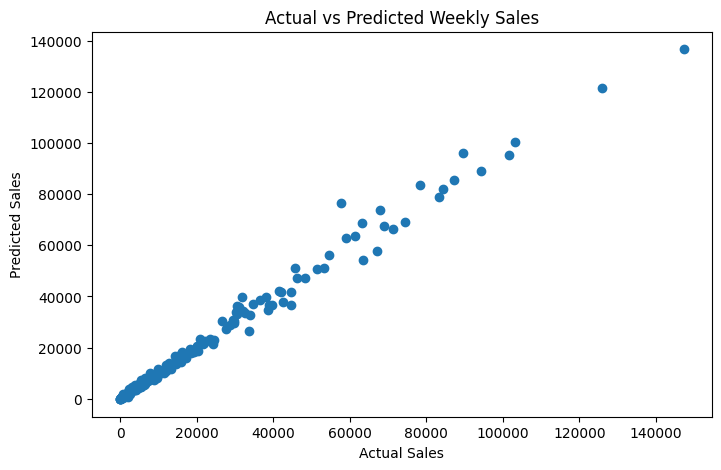

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test[:200], predictions[:200])
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Weekly Sales")
plt.show()

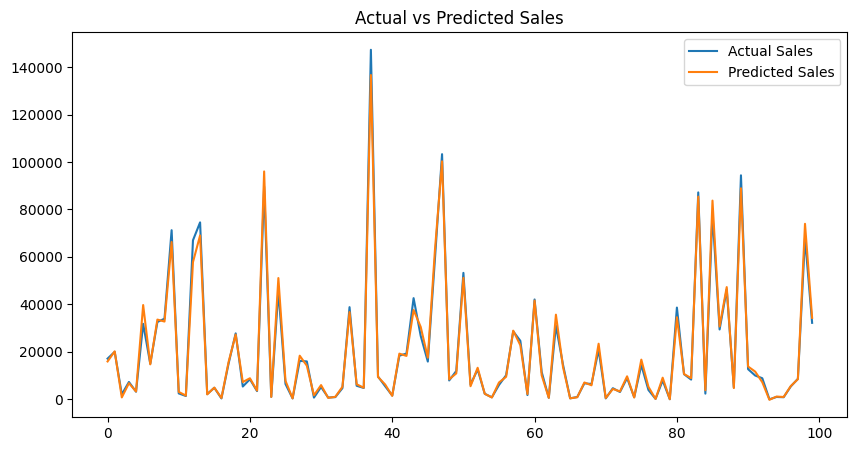

In [10]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label='Actual Sales')
plt.plot(predictions[:100], label='Predicted Sales')
plt.legend()
plt.title('Actual vs Predicted Sales')
plt.show()

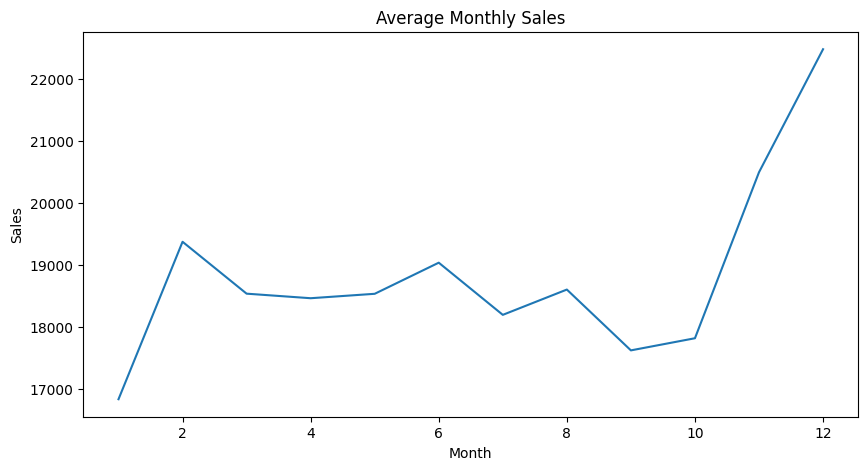

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df.groupby('Month')['Weekly_Sales'].mean().plot()
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

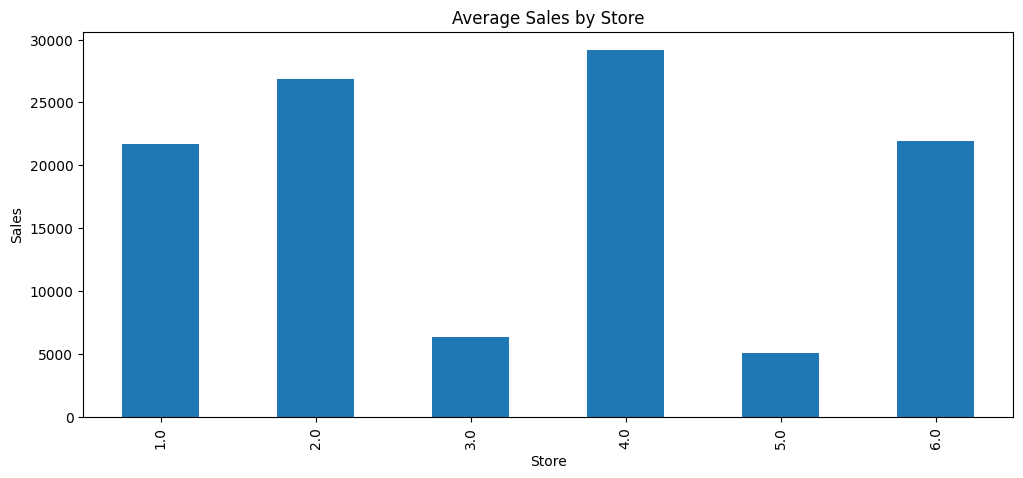

In [22]:
plt.figure(figsize=(12,5))
df.groupby('Store')['Weekly_Sales'].mean().head(20).plot(kind='bar')
plt.title("Average Sales by Store")
plt.ylabel("Sales")
plt.show()

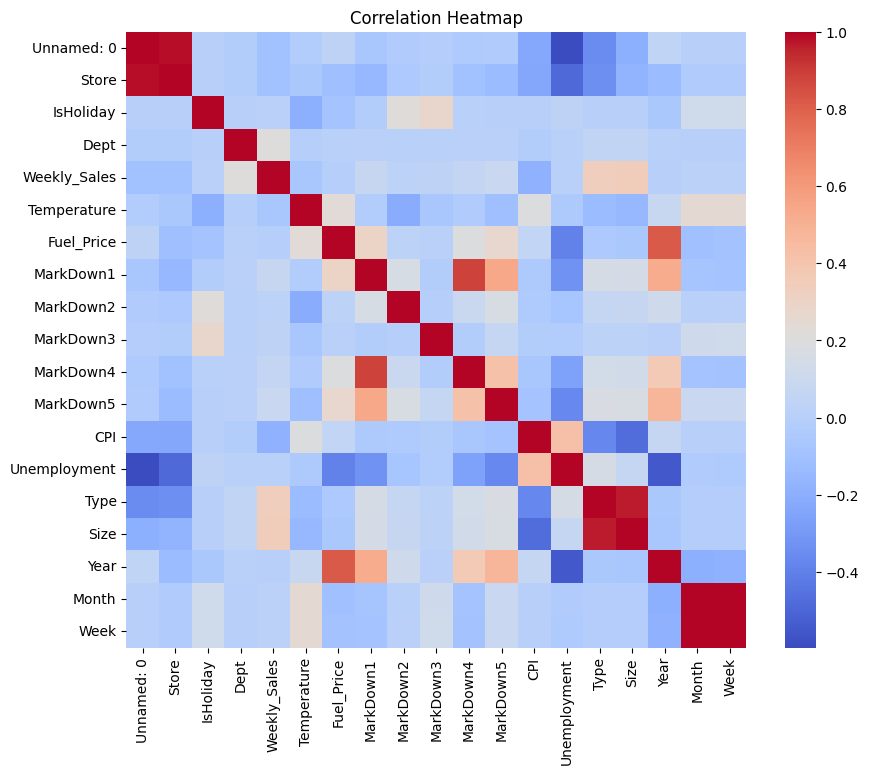

In [23]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=False,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [25]:
lr = LinearRegression()
lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression R2:",
      r2_score(y_test,lr_pred))

Linear Regression R2: 0.1567732326529847


In [26]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree R2:",
      r2_score(y_test,dt_pred))

Decision Tree R2: 0.9728922741712349


In [27]:
print("Random Forest R2:",
      r2_score(y_test,predictions))

Random Forest R2: 0.9798710472734213


In [18]:
import joblib

joblib.dump(model,'sales_model.pkl')

print("Model Saved Successfully")

Model Saved Successfully


In [19]:
from google.colab import files

files.download('sales_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

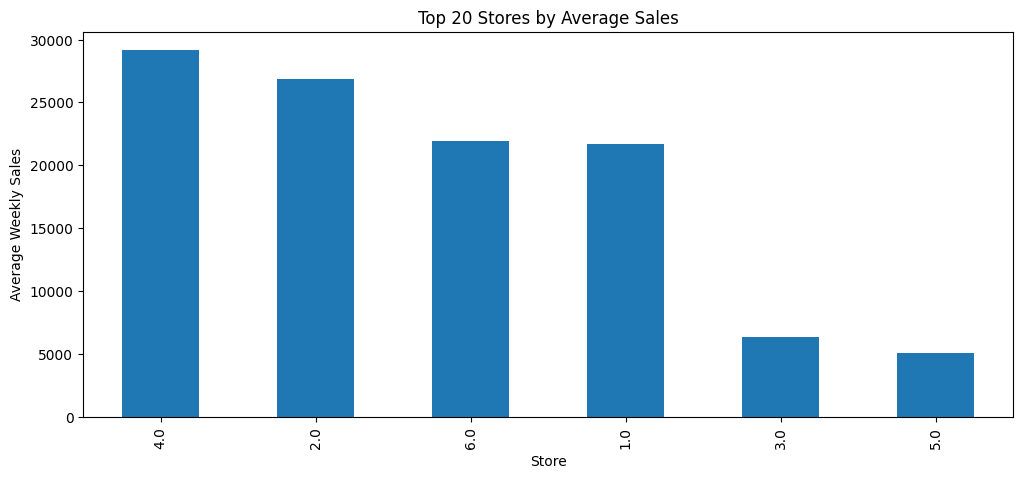

In [28]:
plt.figure(figsize=(12,5))
df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title("Top 20 Stores by Average Sales")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.show()

In [29]:
!pip install seaborn

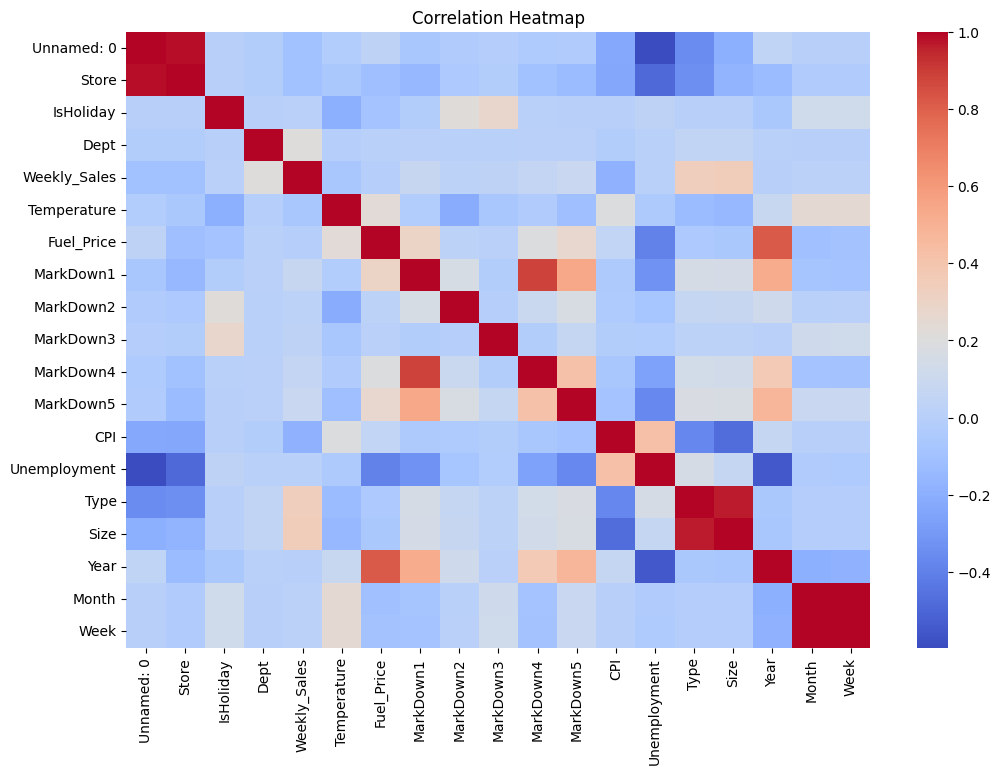

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=False,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()